In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader, Sampler
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import pandas as pd 
import numpy as np
import re, gc, os


/home/prof/ddao/.conda/envs/SAE/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(torch.cuda.is_available())

True


In [3]:
MODEL_NAME = "bert-large-uncased"

In [4]:
# Fix Seed 
import random, os

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Seed fixed: {seed}")

SEED = 123
set_seed(SEED)

Seed fixed: 123


## Load Data

In [5]:
train_df = pd.read_csv("data/matres/train.csv")
test_df  = pd.read_csv("data/matres/test.csv")

# lọc VAGUE trên test
test_df = test_df[test_df["label"] != "VAGUE"].reset_index(drop=True)

# Chia train → train + val
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    random_state=42,
    stratify=train_df["label"]
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print("\nTrain label distribution:")
print(train_df["label"].value_counts())
print("\nVal label distribution:")
print(val_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())

Train: 10404, Val: 1836, Test: 709

Train label distribution:
label
BEFORE    5257
AFTER     3614
VAGUE     1189
EQUAL      344
Name: count, dtype: int64

Val label distribution:
label
BEFORE    927
AFTER     638
VAGUE     210
EQUAL      61
Name: count, dtype: int64

Test label distribution:
label
BEFORE    413
AFTER     265
EQUAL      31
Name: count, dtype: int64


In [6]:
def insert_tags_fast(text_chunk, s1, e1, s2, e2):
    insertions = [(s1, "<e1>"), (e1, "</e1>"), (s2, "<e2>"), (e2, "</e2>")]
    insertions.sort(key=lambda x: x[0], reverse=True)
    text_list = list(text_chunk)
    for pos, tag in insertions:
        if pos == -1:
            continue
        pos = max(0, min(len(text_list), pos))
        text_list.insert(pos, tag)
    return "".join(text_list)


def find_boundary(text, idx, direction="left"):
    limit = 50
    if direction == "left":
        start = max(0, idx - limit)
        sub = text[start:idx]
        matches = list(re.finditer(r"[\s\.]", sub))
        return start + matches[-1].end() if matches else idx
    else:
        end = min(len(text), idx + limit)
        sub = text[idx:end]
        matches = list(re.finditer(r"[\s\.]", sub))
        return idx + matches[0].start() if matches else idx


def create_chunk(full_text, s1, e1, s2, e2, max_len=256):
    span_start = min(s1, s2)
    span_end   = max(e1, e2)
    dist       = span_end - span_start
    max_char_len = (max_len - 10) * 3

    if dist > max_char_len:
        pad = 50
        c1_s = max(0, s1 - pad); c1_e = min(len(full_text), e1 + pad)
        c2_s = max(0, s2 - pad); c2_e = min(len(full_text), e2 + pad)
        chunk1 = insert_tags_fast(full_text[c1_s:c1_e], s1-c1_s, e1-c1_s, -1, -1)
        chunk2 = insert_tags_fast(full_text[c2_s:c2_e], -1, -1, s2-c2_s, e2-c2_s)
        return chunk1 + " [SEP] " + chunk2

    remaining_chars = max_char_len - dist
    padding     = int(remaining_chars / 2)
    raw_start   = max(0, span_start - padding)
    raw_end     = min(len(full_text), span_end + padding)
    final_start = find_boundary(full_text, raw_start, "left")
    final_end   = find_boundary(full_text, raw_end,   "right")
    chunk_text  = full_text[final_start:final_end]
    return insert_tags_fast(
        chunk_text,
        s1 - final_start, e1 - final_start,
        s2 - final_start, e2 - final_start,
    )


def run_preprocessing(df, max_len=256):
    tqdm.pandas(desc="Processing")
    df["processed_text"] = df.progress_apply(
        lambda row: create_chunk(
            row["text"],
            row["entity1_start"], row["entity1_end"],
            row["entity2_start"], row["entity2_end"],
            max_len=max_len,
        ),
        axis=1,
    )
    return df

print("Preprocessing Train...")
train_df = run_preprocessing(train_df)
print("Preprocessing Val...")
val_df = run_preprocessing(val_df)
print("Preprocessing Test...")
test_df  = run_preprocessing(test_df)

Preprocessing Train...


Processing:   0%|          | 0/10404 [00:00<?, ?it/s]

Processing: 100%|██████████| 10404/10404 [00:00<00:00, 47054.60it/s]


Preprocessing Val...


Processing: 100%|██████████| 1836/1836 [00:00<00:00, 46012.21it/s]


Preprocessing Test...


Processing: 100%|██████████| 709/709 [00:00<00:00, 42613.19it/s]


In [7]:
class MatresDataset(Dataset):
    LABEL_MAP = {"BEFORE": 0, "AFTER": 1, "EQUAL": 2, "VAGUE": 3}

    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data       = dataframe.reset_index(drop=True)
        self.tokenizer   = tokenizer
        self.max_length  = max_length

        texts = self.data["processed_text"].tolist()
        encoded = self.tokenizer(
            texts,
            add_special_tokens=True,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        self.input_ids      = encoded["input_ids"]
        self.attention_mask = encoded["attention_mask"]
        self.token_type_ids = encoded.get(
            "token_type_ids", torch.zeros_like(self.input_ids)
        )

        e1_id = self.tokenizer.convert_tokens_to_ids("<e1>")
        e2_id = self.tokenizer.convert_tokens_to_ids("<e2>")
        self.e1_pos = (self.input_ids == e1_id).int().argmax(dim=1)
        self.e2_pos = (self.input_ids == e2_id).int().argmax(dim=1)
        self.labels = torch.tensor(
            [self.LABEL_MAP.get(lbl, -1) for lbl in self.data["label"].tolist()],
            dtype=torch.long,
        )
        self.event1_ids = [f"{doc}_{eid}" for doc, eid in zip(self.data["document_id"], self.data["entity1_id"])]
        self.event2_ids = [f"{doc}_{eid}" for doc, eid in zip(self.data["document_id"], self.data["entity2_id"])]
        self.document_ids = self.data["document_id"].tolist()

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        input_ids      = self.input_ids[idx]
        attention_mask = self.attention_mask[idx]
        token_type_ids = self.token_type_ids[idx]
        e1_pos         = self.e1_pos[idx]
        e2_pos         = self.e2_pos[idx]

        return {
            "input_ids":      input_ids,
            "attention_mask": attention_mask,
            "token_type_ids": token_type_ids,
            "labels":         self.labels[idx],
            "e1_pos":         e1_pos,
            "e2_pos":         e2_pos,
            "event1_id":      self.event1_ids[idx],
            "event2_id":      self.event2_ids[idx],
            "document_id":    self.document_ids[idx],
        }


class SmartBatchSampler(Sampler):
    """Group pairs from the same document to preserve local document context in batches."""

    def __init__(self, dataframe, batch_size):
        self.batch_size  = batch_size
        self.doc_groups  = {}
        for idx, row in dataframe.iterrows():
            self.doc_groups.setdefault(row["document_id"], []).append(idx)
        self.doc_ids = list(self.doc_groups.keys())

    def __iter__(self):
        np.random.shuffle(self.doc_ids)
        batch = []
        for doc_id in self.doc_ids:
            idxs = list(self.doc_groups[doc_id])
            np.random.shuffle(idxs)
            batch.extend(idxs)
            while len(batch) >= self.batch_size:
                yield batch[: self.batch_size]
                batch = batch[self.batch_size :]
        if batch:
            yield batch

    def __len__(self):
        total = sum(len(v) for v in self.doc_groups.values())
        return (total + self.batch_size - 1) // self.batch_size


def collate_fn(batch):
    return {
        "input_ids":      torch.stack([x["input_ids"]      for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"] for x in batch]),
        "token_type_ids": torch.stack([x["token_type_ids"] for x in batch]),
        "labels":         torch.stack([x["labels"]         for x in batch]),
        "e1_pos":         torch.stack([x["e1_pos"]         for x in batch]),
        "e2_pos":         torch.stack([x["e2_pos"]         for x in batch]),
        "event1_id":      [x["event1_id"]   for x in batch],
        "event2_id":      [x["event2_id"]   for x in batch],
        "document_id":    [x["document_id"] for x in batch],
    }



In [8]:
# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.add_special_tokens(
    {"additional_special_tokens": ["<e1>", "</e1>", "<e2>", "</e2>"]}
)


BATCH_SIZE = 64

train_dataset = MatresDataset(train_df, tokenizer)
val_dataset   = MatresDataset(val_df,   tokenizer)
test_dataset  = MatresDataset(test_df,   tokenizer)

train_sampler = SmartBatchSampler(train_df, BATCH_SIZE)

train_loader = DataLoader(train_dataset, batch_sampler=train_sampler,
                          num_workers=16, pin_memory=True, persistent_workers=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=16, pin_memory=True, persistent_workers=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=16, pin_memory=True, persistent_workers=True, collate_fn=collate_fn)

print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} batches")


Train: 163 batches | Val: 29 batches


In [9]:
class GeoTREModel(nn.Module):
    def __init__(self, model_name="roberta-base", num_classes=4,
                 hidden=1024, dropout=0.3, topk=5):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size
        self.topk = topk
        self.num_classes = num_classes

        self.cross_attn = nn.MultiheadAttention(
            embed_dim=hidden_size, num_heads=8,
            dropout=dropout, batch_first=True,
        )
        self.proj = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.pair_proj = nn.Sequential(
            nn.Linear(hidden_size * 4, hidden_size),
            nn.LayerNorm(hidden_size),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.time_head = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2),
        )

        self.cls_head = nn.Sequential(
            nn.Linear(hidden_size * 3, hidden),
            nn.LayerNorm(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

        self.vague_threshold = nn.Parameter(torch.tensor(0.0))
        self.simul_threshold = nn.Parameter(torch.tensor(-2.0))
        self.geo_temp = nn.Parameter(torch.tensor(0.0))

    def _event_repr(self, hidden_states, pos_idx, attention_mask=None):
        B = hidden_states.size(0)
        h = hidden_states[torch.arange(B, device=hidden_states.device), pos_idx]
        query = h.unsqueeze(1)
        key_padding_mask = (attention_mask == 0) if attention_mask is not None else None
        _, attn_weights = self.cross_attn(
            query=query, key=hidden_states, value=hidden_states,
            key_padding_mask=key_padding_mask,
        )
        weights = attn_weights.squeeze(1)
        topk_weights, topk_idx = weights.topk(self.topk, dim=-1)
        topk_weights = topk_weights / (topk_weights.sum(dim=-1, keepdim=True) + 1e-9)
        topk_vectors = hidden_states[
            torch.arange(B, device=hidden_states.device).unsqueeze(1).expand_as(topk_idx), topk_idx
        ]
        h_context = (topk_weights.unsqueeze(-1) * topk_vectors).sum(dim=1)
        return self.proj(torch.cat([h, h_context], dim=-1))

    def _pair_repr(self, h1, h2):
        return self.pair_proj(torch.cat([h1, h2, torch.abs(h1 - h2), h1 * h2], dim=-1))

    def _time_interval(self, h_event, h_pair):
        out = self.time_head(torch.cat([h_event, h_pair], dim=-1))
        s = out[:, 0]
        e = s + F.softplus(out[:, 1]) + 0.05
        return s, e

    def _compute_geo_logits(self, s1, e1, s2, e2):
        logit_before = s2 - e1
        logit_after = s1 - e2
        tol = F.softplus(self.simul_threshold)
        dist = torch.abs(s2 - s1) + torch.abs(e1 - e2)
        logit_equal = 2 * tol - dist

        logits_geo_ord = torch.stack([
            logit_before,
            logit_after,
            logit_equal,
        ], dim=1)

        temp = F.softplus(self.geo_temp) + 0.1
        logits_geo_ord = logits_geo_ord / temp
        logit_vague = self.vague_threshold - torch.logsumexp(logits_geo_ord, dim=1)
        return torch.cat([logits_geo_ord, logit_vague.unsqueeze(1)], dim=1)

    def _fusion_probs(self, logits_sem, logits_geo, eps=1e-8):
        p_sem = F.softmax(logits_sem.float(), dim=-1).clamp(min=eps)
        p_geo = F.softmax(logits_geo.float(), dim=-1).clamp(min=eps)
        p_fuse = p_sem * p_geo
        return p_fuse / p_fuse.sum(dim=-1, keepdim=True).clamp(min=eps)

    def forward(self, input_ids, attention_mask, e1_pos, e2_pos, token_type_ids=None):
        H = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids,
        ).last_hidden_state

        h1 = self._event_repr(H, e1_pos, attention_mask)
        h2 = self._event_repr(H, e2_pos, attention_mask)
        h_pair = self._pair_repr(h1, h2)

        s1, e1 = self._time_interval(h1, h_pair)
        s2, e2 = self._time_interval(h2, h_pair)

        logits_sem = self.cls_head(torch.cat([h1, h2, h_pair], dim=1))
        logits_geo = self._compute_geo_logits(s1, e1, s2, e2)
        p_fuse = self._fusion_probs(logits_sem, logits_geo)

        return s1, e1, s2, e2, logits_sem, logits_geo, p_fuse


In [10]:
class MATRESLoss(nn.Module):
    """
    total = L_fuse + lambda_struct * L_temporal + lambda_agree * L_agree

    L_fuse is the only supervised classification loss.
    L_temporal constrains the latent time geometry.
    L_agree encourages semantic and geometric heads to support the same distribution.
    """

    def __init__(self, lambda_struct=0.3, lambda_agree=0.1,
                 temporal_margin=0.1, equal_margin=0.1):
        super().__init__()
        self.register_buffer(
            "class_weights", torch.tensor([1.0, 1.4, 8.0, 0.1])
        )
        self.lambda_struct = lambda_struct
        self.lambda_agree = lambda_agree
        self.temporal_margin = temporal_margin
        self.equal_margin = equal_margin
        print(f"[MATRESLoss] L_fuse + {lambda_struct}*L_temporal + {lambda_agree}*JS_agree")

    def _agreement_loss(self, logits_sem, logits_geo, eps=1e-8):
        p_sem = F.softmax(logits_sem.float(), dim=-1).clamp(min=eps)
        p_geo = F.softmax(logits_geo.float(), dim=-1).clamp(min=eps)
        p_mid = (0.5 * (p_sem + p_geo)).clamp(min=eps)
        js_sem = (p_sem * (p_sem.log() - p_mid.log())).sum(dim=-1)
        js_geo = (p_geo * (p_geo.log() - p_mid.log())).sum(dim=-1)
        return 0.5 * (js_sem + js_geo).mean()

    def _temporal_logic_loss(self, s1, e1, s2, e2, labels):
        before_gap = s2 - e1
        after_gap = s1 - e2
        equal_dist = torch.abs(s2 - s1) + torch.abs(e1 - e2)
        losses = []

        before_mask = labels == 0
        if before_mask.any():
            losses.append(F.relu(self.temporal_margin - before_gap[before_mask]).mean())

        after_mask = labels == 1
        if after_mask.any():
            losses.append(F.relu(self.temporal_margin - after_gap[after_mask]).mean())

        equal_mask = labels == 2
        if equal_mask.any():
            losses.append(F.relu(equal_dist[equal_mask] - self.equal_margin).mean())

        if not losses:
            return torch.tensor(0.0, device=labels.device)
        return torch.stack(losses).mean()

    def forward(self, s1, e1, s2, e2, labels, logits_sem, logits_geo, p_fuse,
                event1_ids=None, event2_ids=None):
        w = self.class_weights.to(logits_sem.device).float()
        fuse_loss = F.nll_loss(p_fuse.clamp_min(1e-8).log(), labels, weight=w)
        temporal_loss = self._temporal_logic_loss(s1, e1, s2, e2, labels)
        agree_loss = self._agreement_loss(logits_sem, logits_geo)

        total = (fuse_loss
                 + self.lambda_struct * temporal_loss
                 + self.lambda_agree * agree_loss)

        return total, fuse_loss, temporal_loss, agree_loss


In [11]:
LABEL_NAMES = ["BEFORE", "AFTER", "EQUAL", "VAGUE"]
NUM_CLASSES  = 4
VAGUE_IDX    = 3
EVAL_LABELS  = list(range(3))
FULL_LABELS  = list(range(4))

def train_epoch(model, loader, criterion, optimizer, device, scheduler=None, scaler=None):
    model.train()
    total = fuse_sum = temporal_sum = agree_sum = 0.0

    bar = tqdm(loader, desc="  Train")
    amp_enabled = (device.type == "cuda")
    if scaler is None:
        scaler = torch.amp.GradScaler("cuda", enabled=amp_enabled)

    for batch in bar:
        input_ids      = batch["input_ids"].to(device, non_blocking=True)
        mask           = batch["attention_mask"].to(device, non_blocking=True)
        token_type_ids = batch["token_type_ids"].to(device, non_blocking=True)
        e1_pos         = batch["e1_pos"].to(device, non_blocking=True)
        e2_pos         = batch["e2_pos"].to(device, non_blocking=True)
        labels         = batch["labels"].to(device, non_blocking=True)
        ev1_ids        = batch["event1_id"]
        ev2_ids        = batch["event2_id"]

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type="cuda", enabled=amp_enabled):
            s1, e1, s2, e2, logits_sem, logits_geo, p_fuse = model(
                input_ids, mask, e1_pos, e2_pos, token_type_ids
            )

            loss, fuse_loss, temporal_loss, agree_loss = criterion(
                s1, e1, s2, e2, labels,
                logits_sem, logits_geo, p_fuse,
                ev1_ids, ev2_ids,
            )
            if loss.dim() > 0:
                loss = loss.mean()

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        if scheduler:
            scheduler.step()

        total        += loss.item()
        fuse_sum     += fuse_loss.item()
        temporal_sum += temporal_loss.item()
        agree_sum    += agree_loss.item()

        bar.set_postfix(
            loss=f"{loss.item():.3f}",
            fuse=f"{fuse_loss.item():.3f}",
            temp=f"{temporal_loss.item():.3f}",
            agree=f"{agree_loss.item():.3f}",
        )

    n = len(loader)
    return total/n, fuse_sum/n, temporal_sum/n, agree_sum/n


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total = 0.0
    all_preds, all_labels = [], []

    amp_enabled = (device.type == "cuda")

    for batch in tqdm(loader, desc="  Val  "):
        input_ids      = batch["input_ids"].to(device, non_blocking=True)
        mask           = batch["attention_mask"].to(device, non_blocking=True)
        token_type_ids = batch["token_type_ids"].to(device, non_blocking=True)
        e1_pos         = batch["e1_pos"].to(device, non_blocking=True)
        e2_pos         = batch["e2_pos"].to(device, non_blocking=True)
        labels         = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast(device_type="cuda", enabled=amp_enabled):
            s1, e1, s2, e2, logits_sem, logits_geo, p_fuse = model(
                input_ids, mask, e1_pos, e2_pos, token_type_ids
            )
            loss, fuse_loss, temporal_loss, agree_loss = criterion(
                s1, e1, s2, e2, labels, logits_sem, logits_geo, p_fuse
            )
        if loss.dim() > 0:
            loss = loss.mean()
        total += loss.item()

        preds = p_fuse.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total / len(loader)
    acc      = accuracy_score(all_labels, all_preds)

    mask = np.array(all_labels) != VAGUE_IDX
    f1   = f1_score(np.array(all_labels)[mask], np.array(all_preds)[mask],
                    labels=EVAL_LABELS,
                    average="macro", zero_division=0)

    return avg_loss, acc, f1


In [12]:
if "model"     in dir(): del model
if "optimizer" in dir(): del optimizer
if "criterion" in dir(): del criterion
gc.collect(); torch.cuda.empty_cache()

EPOCHS        = 50
LR            = 2e-5
SAVE_PATH     = "save_models/geotre_matres_bert_large.pth"
LAMBDA_STRUCT = 1.0
LAMBDA_AGREE  = 1.0



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GeoTREModel(model_name=MODEL_NAME, num_classes=NUM_CLASSES)
model.encoder.resize_token_embeddings(len(tokenizer))

if torch.cuda.device_count() > 1:
    print(f"--> {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model.to(device)

scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

criterion = MATRESLoss(
    lambda_struct=LAMBDA_STRUCT,
    lambda_agree=LAMBDA_AGREE,
)
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)

from transformers import get_linear_schedule_with_warmup
total_steps  = len(train_loader) * EPOCHS
warmup_steps = total_steps // 10
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)
print(f"Total steps: {total_steps} | Warmup steps: {warmup_steps}")


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


[MATRESLoss] L_fuse + 1.0*L_temporal + 1.0*JS_agree
Total steps: 8150 | Warmup steps: 815


In [13]:
best_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")

    tr_loss, tr_fuse, tr_temp, tr_agree = train_epoch(
        model, train_loader, criterion, optimizer, device, scheduler, scaler
    )

    val_loss, val_acc, val_f1 = eval_epoch(
        model, val_loader, criterion, device
    )

    print(f"  Train: total={tr_loss:.4f}  fuse={tr_fuse:.4f}  "
          f"temporal={tr_temp:.4f}  agree={tr_agree:.4f}")
    print(f"  Val  : loss={val_loss:.4f}  acc={val_acc:.4f}  macro-F1={val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        core = model.module if isinstance(model, nn.DataParallel) else model
        torch.save(core.state_dict(), SAVE_PATH)
        print(f"  --> Saved! (best F1={best_f1:.4f})")

print(f"\nBest Val Macro-F1: {best_f1:.4f}")



Epoch 1/50


  Train:   0%|          | 0/163 [00:00<?, ?it/s]/home/prof/ddao/.conda/envs/SAE/lib/python3.9/site-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(
  Val  : 100%|██████████| 29/29 [00:06<00:00,  4.20it/s]


  Train: total=2.3116  fuse=1.4904  temporal=0.7374  agree=0.0838
  Val  : loss=1.2606  acc=0.5980  macro-F1=0.4674
  --> Saved! (best F1=0.4674)

Epoch 2/50


  Val  : 100%|██████████| 29/29 [00:06<00:00,  4.54it/s]


  Train: total=1.5264  fuse=1.1108  temporal=0.3579  agree=0.0578
  Val  : loss=1.2771  acc=0.6596  macro-F1=0.5052
  --> Saved! (best F1=0.5052)

Epoch 3/50


...

  Train: total=0.0339  fuse=0.0193  temporal=0.0027  agree=0.0119
  Val  : loss=4.0609  acc=0.7625  macro-F1=0.6424

Epoch 49/50


  Val  : 100%|██████████| 29/29 [00:06<00:00,  4.52it/s]


  Train: total=0.0348  fuse=0.0206  temporal=0.0025  agree=0.0117
  Val  : loss=4.1171  acc=0.7620  macro-F1=0.6420

Epoch 50/50


  Val  : 100%|██████████| 29/29 [00:06<00:00,  4.51it/s]

  Train: total=0.0332  fuse=0.0192  temporal=0.0023  agree=0.0118
  Val  : loss=4.1322  acc=0.7625  macro-F1=0.6423

Best Val Macro-F1: 0.6633


/tmp/ipykernel_946018/2435245602.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  core.load_state_dict(torch.load(SAVE_PATH, map_location=device))
Testing: 100%|█████████

Inference supports 3 strategies: Semantic only, Geometry only, and Full GeoTRE (Learnable Fuse).

  Semantic only
  Acc: 0.7983  |  Micro-F1: 0.7983  |  Macro-F1: 0.4310
              precision    recall  f1-score   support

      BEFORE     0.8862    0.8862    0.8862       413
       AFTER     0.8541    0.7509    0.7992       265
       EQUAL     0.0476    0.0323    0.0385        31
       VAGUE     0.0000    0.0000    0.0000         0

    accuracy                         0.7983       709
   macro avg     0.4470    0.4174    0.4310       709
weighted avg     0.8375    0.7983    0.8166       709


  Geometry only
  Acc: 0.8195  |  Micro-F1: 0.8195  |  Macro-F1: 0.4636
              precision    recall  f1-score   support

      BEFORE     0.8762    0.8910    0.8836       413
       AFTER     0.8519    0.7811    0.8150       265
       EQUAL     0.1304    0.1935    0.1558        31
       VAGUE     0.0000    0.0000    0.0000         0

    accuracy                         0.8195       

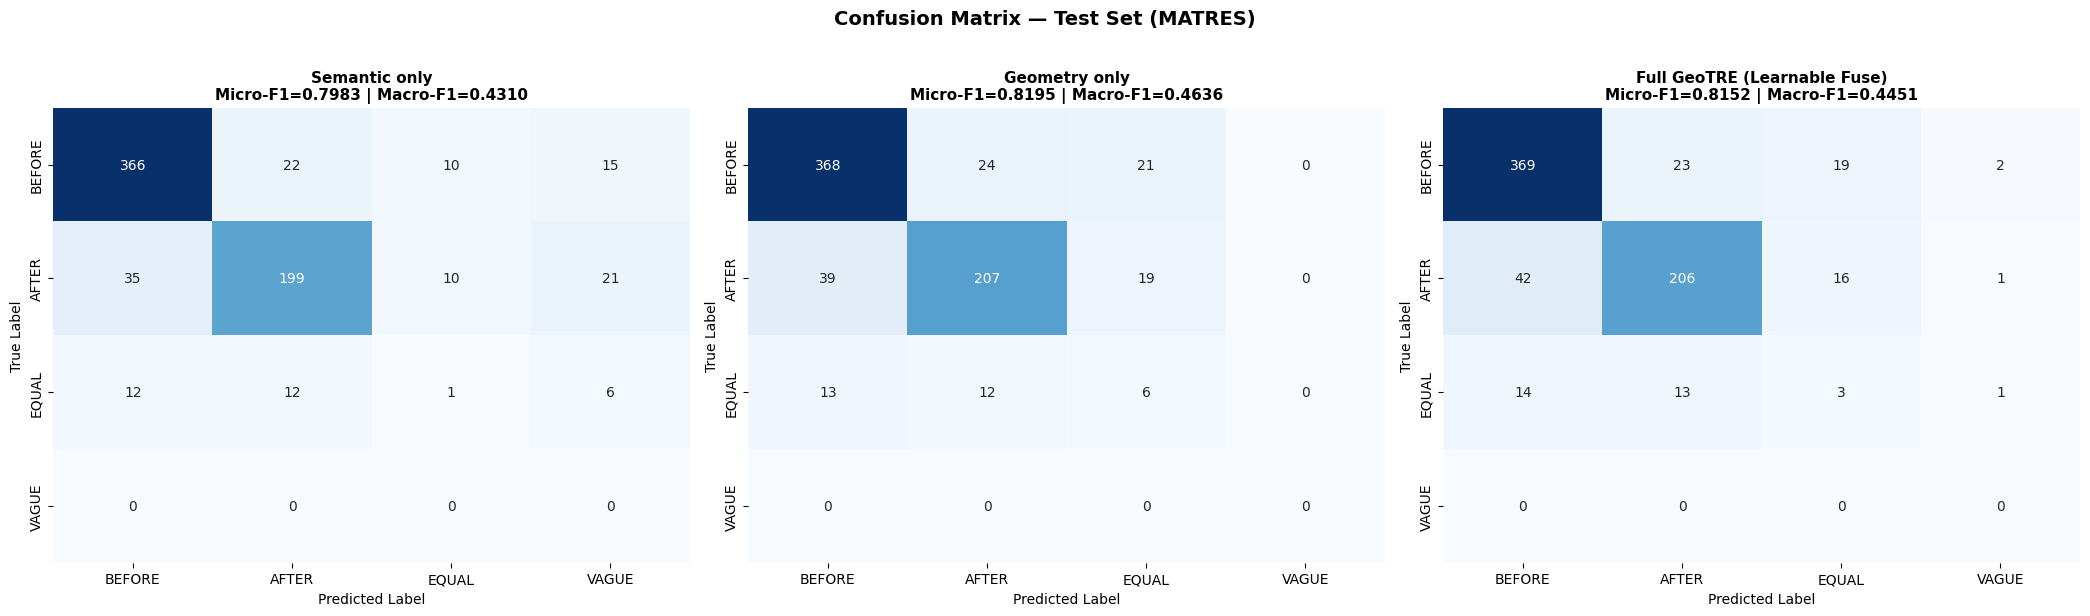


  SUMMARY — TEST SET
  Strategy                 |      Acc |   Micro-F1 |   Macro-F1
  -------------------------+----------+------------+-----------
  Semantic only            |   0.7983 |     0.7983 |     0.4310
  Geometry only            |   0.8195 |     0.8195 |     0.4636
  Full GeoTRE (Learnable Fuse) |   0.8152 |     0.8152 |     0.4451


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load best model
core = model.module if isinstance(model, nn.DataParallel) else model
core.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.to(device)
model.eval()

# Collect outputs
all_p_fuse = []
all_logits_sem = []
all_logits_geo = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch["input_ids"].to(device, non_blocking=True)
        mask = batch["attention_mask"].to(device, non_blocking=True)
        token_type_ids = batch["token_type_ids"].to(device, non_blocking=True)
        e1_pos = batch["e1_pos"].to(device, non_blocking=True)
        e2_pos = batch["e2_pos"].to(device, non_blocking=True)
        labels = batch["labels"].to(device, non_blocking=True)

        with torch.amp.autocast(device_type="cuda", enabled=(device.type == "cuda")):
            s1, e1, s2, e2, logits_sem, logits_geo, p_fuse = model(
                input_ids, mask, e1_pos, e2_pos, token_type_ids
            )

        all_p_fuse.append(p_fuse.cpu())
        all_logits_sem.append(logits_sem.cpu())
        all_logits_geo.append(logits_geo.cpu())
        all_labels.extend(labels.cpu().numpy())

all_p_fuse = torch.cat(all_p_fuse, dim=0)
all_logits_sem = torch.cat(all_logits_sem, dim=0)
all_logits_geo = torch.cat(all_logits_geo, dim=0)
all_labels = np.array(all_labels)

print("Inference supports 3 strategies: Semantic only, Geometry only, and Full GeoTRE (Learnable Fuse).")

# Strategy outputs
preds_sem = all_logits_sem.argmax(dim=-1).numpy()
preds_geo = all_logits_geo.argmax(dim=-1).numpy()
preds_fuse = all_p_fuse.argmax(dim=-1).numpy()

strategies = [
    ("Semantic only", preds_sem),
    ("Geometry only", preds_geo),
    ("Full GeoTRE (Learnable Fuse)", preds_fuse),
]

results = []
for name, preds in strategies:
    micro_f1 = f1_score(all_labels, preds, labels=FULL_LABELS, average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, preds, labels=FULL_LABELS, average="macro", zero_division=0)
    acc = accuracy_score(all_labels, preds)
    results.append((name, acc, micro_f1, macro_f1))
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"  Acc: {acc:.4f}  |  Micro-F1: {micro_f1:.4f}  |  Macro-F1: {macro_f1:.4f}")
    print(f"{'='*60}")
    print(classification_report(
        all_labels, preds,
        target_names=LABEL_NAMES,
        labels=FULL_LABELS,
        zero_division=0, digits=4,
    ))

# Confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for ax, (name, preds) in zip(axes, strategies):
    cm = confusion_matrix(all_labels, preds, labels=FULL_LABELS)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
        ax=ax, cbar=False,
    )
    micro_f1 = f1_score(all_labels, preds, labels=FULL_LABELS, average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, preds, labels=FULL_LABELS, average="macro", zero_division=0)
    ax.set_title(f"{name}\nMicro-F1={micro_f1:.4f} | Macro-F1={macro_f1:.4f}", fontsize=11, fontweight='bold')
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
plt.suptitle("Confusion Matrix — Test Set (MATRES)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Summary
print("\n" + "="*90)
print("  SUMMARY — TEST SET")
print("="*90)
print(f"  {'Strategy':<24} | {'Acc':>8} | {'Micro-F1':>10} | {'Macro-F1':>10}")
print(f"  {'-'*24}-+-{'-'*8}-+-{'-'*10}-+-{'-'*10}")
for name, acc, micro_f1, macro_f1 in results:
    print(f"  {name:<24} | {acc:>8.4f} | {micro_f1:>10.4f} | {macro_f1:>10.4f}")
print("="*90)
